<a href="https://colab.research.google.com/github/NguyenTruongV/data_analysis_deep-learning/blob/main/Lab_5.1/fashion-mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

In [1]:
from torchvision import datasets
import torch

data_folder = '~/data/FMNIST'

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 279kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.09MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.40MB/s]


In [2]:
tr_images = fmnist.data
tr_targets = fmnist.targets

In [3]:
unique_values = tr_targets.unique()

print(f'tr_images & tr_targets:')
print(f'X - {tr_images.shape}')
print(f'Y - {tr_targets.shape}')
print(f'Unique Values : {unique_values}')

print(f'{len(unique_values)} class classification')
print(f'Classes: {fmnist.classes}')

tr_images & tr_targets:
X - torch.Size([60000, 28, 28])
Y - torch.Size([60000])
Unique Values : tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
10 class classification
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


In [4]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

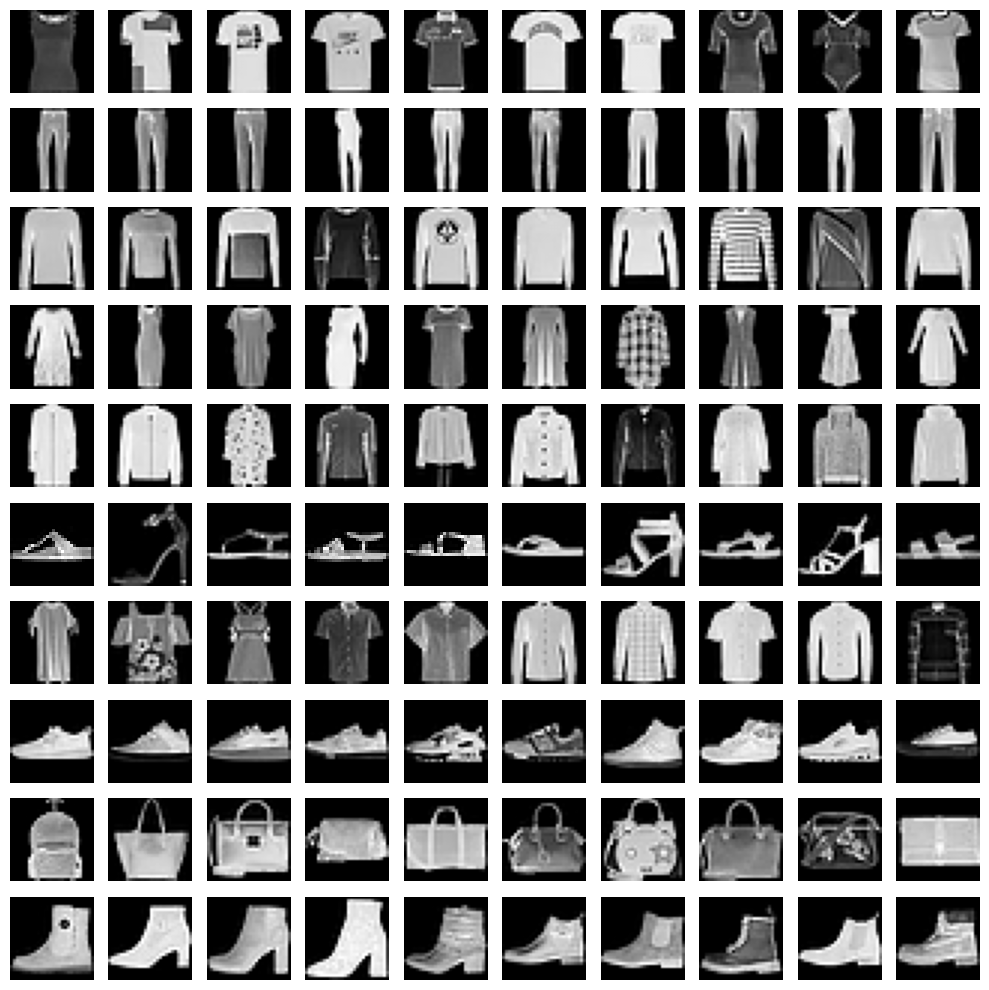

In [5]:
R, C = len(tr_targets.unique()), 10

fig, ax = plt.subplots(R, C, figsize=(10,10))

for label_class, plot_row in enumerate(ax):

    label_x_rows = np.where(tr_targets == label_class)[0]

    for plot_cell in plot_row:
        plot_cell.grid(False)
        plot_cell.axis('off')

        ix = np.random.choice(label_x_rows)

        x = tr_images[ix]

        plot_cell.imshow(x, cmap='gray')

plt.tight_layout()

In [6]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import numpy as np

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [8]:
class FMNISTDataset(Dataset):

    def __init__(self, x, y):

        x = x.float()/255
        x = x.view(-1,28*28)

        self.x = x
        self.y = y

    def __getitem__(self, ix):

        x = self.x[ix]
        y = self.y[ix]

        return x.to(device), y.to(device)

    def __len__(self):

        return len(self.x)

In [9]:
def get_data():

    train = FMNISTDataset(tr_images, tr_targets)

    trn_dl = DataLoader(
        train,
        batch_size=32,
        shuffle=True
    )

    return trn_dl

In [10]:
from torch.optim import SGD

def get_model():

    model = nn.Sequential(

        nn.Linear(28*28,1000),
        nn.ReLU(),

        nn.Linear(1000,10)

    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    optimizer = SGD(
        model.parameters(),
        lr=1e-2
    )

    return model, loss_fn, optimizer

In [11]:
def train_batch(x, y, model, opt, loss_fn):

    model.train()

    prediction = model(x)

    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()

    opt.step()

    opt.zero_grad()

    return batch_loss.item()

In [12]:
@torch.no_grad()
def accuracy(x, y, model):

    model.eval()

    prediction = model(x)

    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()

In [13]:
trn_dl = get_data()

model, loss_fn, optimizer = get_model()

losses = []
accuracies = []

for epoch in range(5):

    print(epoch)

    epoch_losses = []
    epoch_accuracies = []

    for ix, batch in enumerate(iter(trn_dl)):

        x, y = batch

        batch_loss = train_batch(
            x, y, model, optimizer, loss_fn
        )

        epoch_losses.append(batch_loss)

    epoch_loss = np.array(epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):

        x, y = batch

        is_correct = accuracy(x, y, model)

        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)

    accuracies.append(epoch_accuracy)

0
1
2
3
4


/tmp/ipykernel_179/2987638419.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(


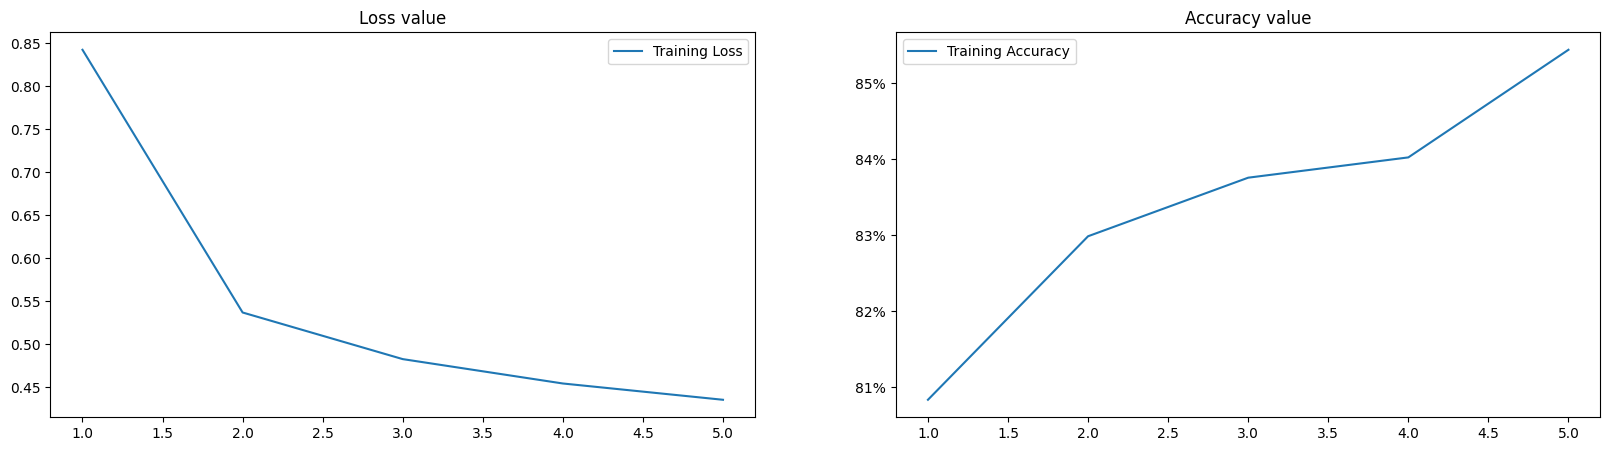

In [14]:
epochs = np.arange(5)+1

plt.figure(figsize=(20,5))

plt.subplot(121)
plt.title("Loss value")
plt.plot(epochs, losses, label="Training Loss")
plt.legend()

plt.subplot(122)
plt.title("Accuracy value")
plt.plot(epochs, accuracies, label="Training Accuracy")

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()]
)

plt.legend()

In [15]:
trn_dl = get_data()

model, loss_fn, optimizer = get_model()

losses, accuracies = [], []

for epoch in range(20):

    print("Epoch:", epoch)

    epoch_losses = []
    epoch_accuracies = []

    for batch in trn_dl:

        x, y = batch

        loss = train_batch(x, y, model, optimizer, loss_fn)

        epoch_losses.append(loss)

    epoch_loss = np.mean(epoch_losses)

    for batch in trn_dl:

        x, y = batch

        acc = accuracy(x, y, model)

        epoch_accuracies.extend(acc)

    epoch_accuracy = np.mean(epoch_accuracies)

    print("Loss:", epoch_loss)
    print("Accuracy:", epoch_accuracy)

Epoch: 0
Loss: 0.8420074207782745
Accuracy: 0.8073333333333333
Epoch: 1
Loss: 0.5375991935253144
Accuracy: 0.8264666666666667
Epoch: 2
Loss: 0.4830620276530584
Accuracy: 0.8410666666666666
Epoch: 3
Loss: 0.45462897884051007
Accuracy: 0.8494833333333334
Epoch: 4
Loss: 0.4350408369263013
Accuracy: 0.8553666666666667
Epoch: 5
Loss: 0.42037606219450635
Accuracy: 0.8585166666666667
Epoch: 6
Loss: 0.40805868114630384
Accuracy: 0.8613166666666666
Epoch: 7
Loss: 0.39657751322189966
Accuracy: 0.8669333333333333
Epoch: 8
Loss: 0.3872108386317889
Accuracy: 0.8696166666666667
Epoch: 9
Loss: 0.3782669813315074
Accuracy: 0.8703666666666666
Epoch: 10
Loss: 0.37013240987459817
Accuracy: 0.871
Epoch: 11
Loss: 0.36264443531433743
Accuracy: 0.8785333333333334
Epoch: 12
Loss: 0.35628105121850967
Accuracy: 0.87895
Epoch: 13
Loss: 0.3499795048952103
Accuracy: 0.8785166666666666
Epoch: 14
Loss: 0.344175006087621
Accuracy: 0.8807666666666667
Epoch: 15
Loss: 0.3381661886413892
Accuracy: 0.8771166666666667
Epoc

In [17]:
import matplotlib.pyplot as plt
import numpy as np

In [18]:
epochs = np.arange(20) + 1

ValueError: x and y must have same first dimension, but have shapes (20,) and (0,)

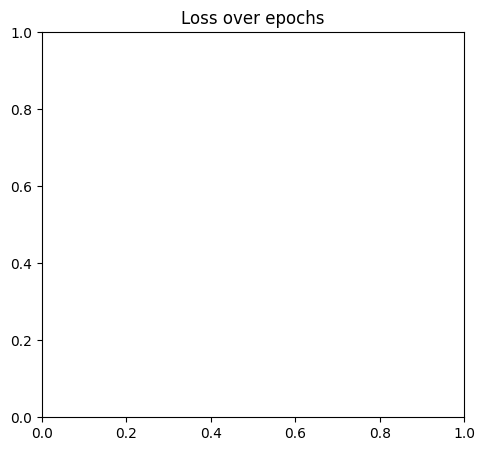

In [19]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.title("Loss over epochs")
plt.plot(epochs, losses, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.title("Accuracy over epochs")
plt.plot(epochs, accuracies, label="Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.gca().set_yticklabels(
    ['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()]
)

plt.legend()

plt.show()

In [20]:
losses = []
accuracies = []

for epoch in range(20):

    epoch_losses = []
    epoch_accuracies = []

    for batch in trn_dl:
        x,y = batch
        loss = train_batch(x,y,model,optimizer,loss_fn)
        epoch_losses.append(loss)

    epoch_loss = np.mean(epoch_losses)

    for batch in trn_dl:
        x,y = batch
        acc = accuracy(x,y,model)
        epoch_accuracies.extend(acc)

    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

    print("Epoch:",epoch)
    print("Loss:",epoch_loss)
    print("Accuracy:",epoch_accuracy)

Epoch: 0
Loss: 0.3148566461940606
Accuracy: 0.8925666666666666
Epoch: 1
Loss: 0.3104787468969822
Accuracy: 0.89125
Epoch: 2
Loss: 0.3062784037053585
Accuracy: 0.8921666666666667
Epoch: 3
Loss: 0.30259500944018364
Accuracy: 0.8954333333333333
Epoch: 4
Loss: 0.2983939425309499
Accuracy: 0.8955833333333333
Epoch: 5
Loss: 0.2950418007314205
Accuracy: 0.9002166666666667
Epoch: 6
Loss: 0.29154558253884316
Accuracy: 0.8948666666666667
Epoch: 7
Loss: 0.28817286571462947
Accuracy: 0.90115
Epoch: 8
Loss: 0.2843095342199008
Accuracy: 0.9023666666666667
Epoch: 9
Loss: 0.2810928461154302
Accuracy: 0.9045833333333333
Epoch: 10
Loss: 0.27738863209883374
Accuracy: 0.8984166666666666
Epoch: 11
Loss: 0.27472125358581545
Accuracy: 0.9069
Epoch: 12
Loss: 0.27152379419008893
Accuracy: 0.9059833333333334
Epoch: 13
Loss: 0.2691476076304913
Accuracy: 0.9095333333333333
Epoch: 14
Loss: 0.26558143806656204
Accuracy: 0.90975
Epoch: 15
Loss: 0.26318034250537553
Accuracy: 0.9061833333333333
Epoch: 16
Loss: 0.26080

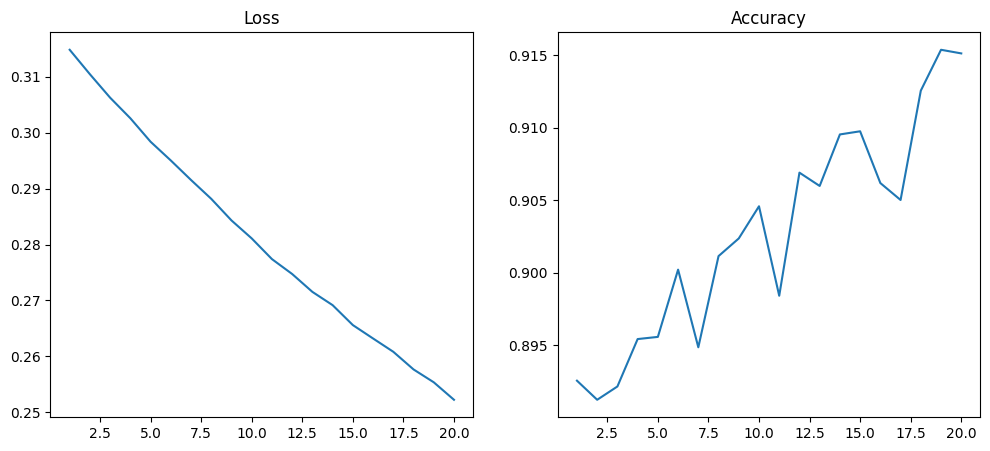

In [21]:
epochs = np.arange(len(losses)) + 1

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, losses)
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(epochs, accuracies)
plt.title("Accuracy")

plt.show()